# Image classifier for plant leaf diseases.
Through two phases: building a CNN from scratch to understand the mechanics,

then fine-tuning a pretrained model to see what state-of-the-art transfer learning buys you.

- Data pipeline: Use tf.data with ImageDataGenerator.

    Apply augmentation (flip, rotation, zoom) and visualize effects.



---


- Phase 1 : Custom CNN: Design a 4-6 layer CNN with Conv2D → MaxPool → Dropout blocks.

    Train and plot accuracy/loss.



---



- Phase 2 : Transfer Learning: Fine-tune EfficientNetB0 or MobileNetV2.

    Freeze base layers, train head, then unfreeze and fine-tune with a low learning rate.


---


- Visualization: Plot 9 sample predictions with true/predicted labels.

    Show the confusion matrix across all classes.

---

- Analysis: Compare Phase 1 vs Phase 2 accuracy.

    How many parameters does each model have?
    
    What does dropout prevent?



In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (6).json


{'kaggle (6).json': b'{"username":"habibafurany","key":"60f60a9a2d21b1ebc513e3cdeae4f488"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
# !unzip new-plant-diseases-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
new-plant-diseases-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [5]:
base_path = "/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_path + "/train",
    image_size = (160, 160),
    batch_size=8
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_path + "/valid",
    image_size = (160, 160),
    batch_size=8
)

class_names = train_ds.class_names
print(class_names)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Sep

In [6]:
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

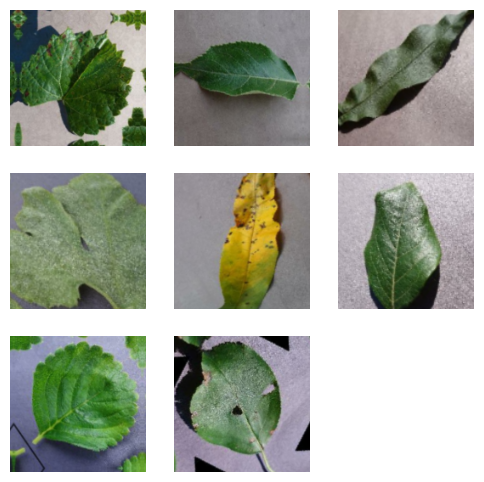

In [31]:
plt.figure(figsize=(6,6))

for images, labels in train_ds.take(1):
    batch_size = images.shape[0]

    for i in range(batch_size):
        ax = plt.subplot(3,3,i+1)

        img = images[i]
        img = tf.expand_dims(img, axis=0)

        aug_img = data_augmentation(img)[0]

        plt.imshow(aug_img.numpy().astype("uint8"))
        plt.axis("off")

plt.show()

In [9]:
model1 = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(160,160,3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),  # lighter than flatten

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 131s 13ms/step - accuracy: 0.3966 - loss: 2.0368 - val_accuracy: 0.7124 - val_loss: 0.9525
Epoch 2/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 108s 12ms/step - accuracy: 0.6922 - loss: 0.9960 - val_accuracy: 0.8273 - val_loss: 0.5782
Epoch 3/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 139s 11ms/step - accuracy: 0.7894 - loss: 0.6784 - val_accuracy: 0.8956 - val_loss: 0.3368
Epoch 4/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 106s 11ms/step - accuracy: 0.8329 - loss: 0.5289 - val_accuracy: 0.9019 - val_loss: 0.3214
Epoch 5/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 144s 12ms/step - accuracy: 0.8613 - loss: 0.4401 - val_accuracy: 0.9196 - val_loss: 0.2463


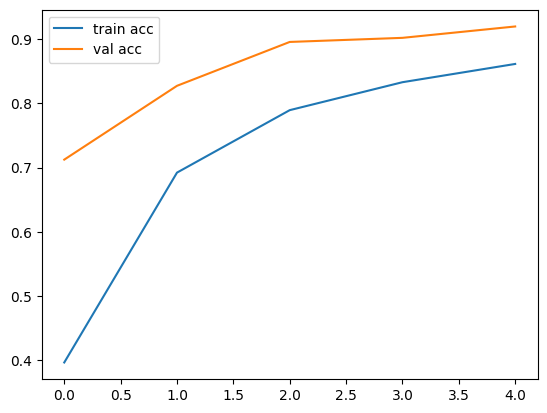

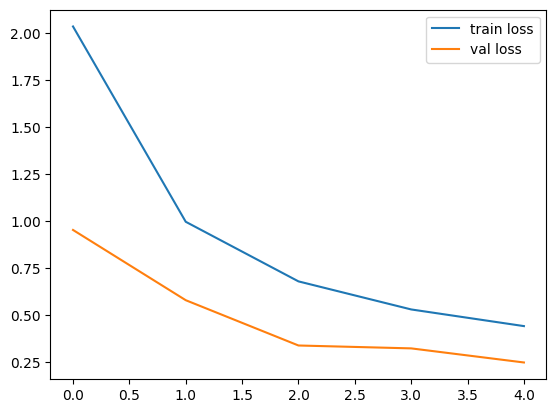

In [11]:
plt.plot(history1.history['accuracy'], label='train acc')
plt.plot(history1.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history1.history['loss'], label='train loss')
plt.plot(history1.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [15]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [16]:
model2 = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

In [17]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 225s 24ms/step - accuracy: 0.6906 - loss: 1.0463 - val_accuracy: 0.8444 - val_loss: 0.5173
Epoch 2/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 202s 23ms/step - accuracy: 0.7510 - loss: 0.8348 - val_accuracy: 0.8659 - val_loss: 0.4461
Epoch 3/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 270s 23ms/step - accuracy: 0.7648 - loss: 0.7841 - val_accuracy: 0.8625 - val_loss: 0.4712
Epoch 4/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 202s 22ms/step - accuracy: 0.7761 - loss: 0.7525 - val_accuracy: 0.8658 - val_loss: 0.4625
Epoch 5/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 200s 22ms/step - accuracy: 0.7847 - loss: 0.7195 - val_accuracy: 0.8743 - val_loss: 0.4513


In [18]:
base_model.trainable = True

model2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 814s 89ms/step - accuracy: 0.6444 - loss: 1.3444 - val_accuracy: 0.6941 - val_loss: 1.7403
Epoch 2/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 784s 89ms/step - accuracy: 0.7795 - loss: 0.7671 - val_accuracy: 0.7557 - val_loss: 1.2787
Epoch 3/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 800s 90ms/step - accuracy: 0.8252 - loss: 0.5915 - val_accuracy: 0.8407 - val_loss: 0.6605
Epoch 4/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 797s 90ms/step - accuracy: 0.8510 - loss: 0.4984 - val_accuracy: 0.8503 - val_loss: 0.6953
Epoch 5/5
8787/8787 ━━━━━━━━━━━━━━━━━━━━ 795s 90ms/step - accuracy: 0.8713 - loss: 0.4268 - val_accuracy: 0.8653 - val_loss: 0.5829


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


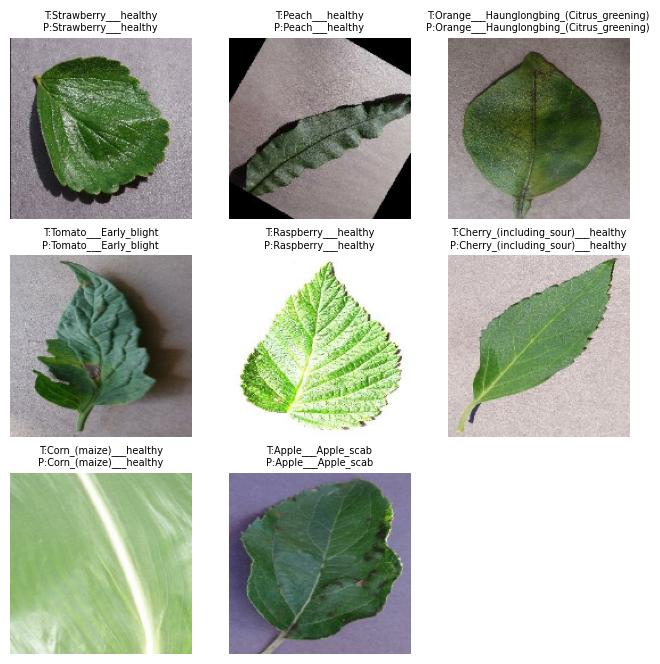

In [22]:
plt.figure(figsize=(8,8))

for images, labels in val_ds.take(1):
    preds = model2.predict(images)

    batch_size = images.shape[0]

    for i in range(batch_size):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        pred = class_names[np.argmax(preds[i])]
        true = class_names[labels[i]]

        plt.title(f"T:{true}\nP:{pred}", fontsize=7)
        plt.axis("off")

plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model2.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))


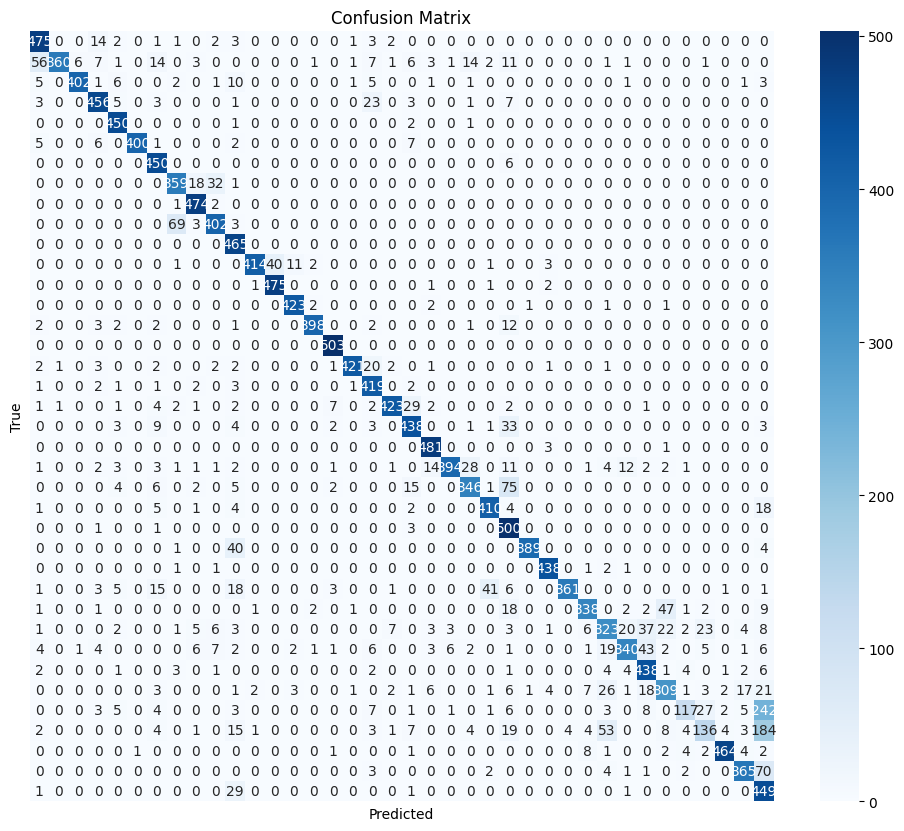

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues',annot=True , fmt='d',xticklabels=False, yticklabels=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [24]:
print("Custom CNN Params:", model1.count_params())
print("Transfer Learning Params:", model2.count_params())

Custom CNN Params: 114662
Transfer Learning Params: 2431974


CNN achieved higher accuracy in this case because it was fully trained on the specific dataset, allowing it to learn dataset-specific features.

Transfer learning models like MobileNetV2 rely on general features learned from ImageNet, which may not always perfectly match the target dataset.

Dropout is a regularization technique that randomly disables neurons during training.

* This helps prevent overfitting by forcing the model to learn more robust and generalized features instead of memorizing the training data.

Custom CNN Parameters: 114662  
Transfer Learning Parameters: 2431974  

The transfer learning model has significantly more parameters because it uses a pretrained MobileNetV2 backbone.
